In [5]:
# Optional Colab-only cell: mount Google Drive when running in Colab; skipped locally.
try:
    from google.colab import drive  # type: ignore
    drive.mount("/content/drive")
except ImportError:
    pass

Mounted at /content/drive


In [6]:

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import pickle
import os

# =====================================================
# CONFIGURATION: Hyperparameters and device setup
# =====================================================

LATENT_DIM = 16  # Dimension of latent space (compressed representation)
BATCH_SIZE = 64  # Images per batch during training
LR = 1e-3  # Learning rate for Adam optimizer
EPOCHS = 50  # Number of complete passes through dataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")
print(f"Configuration: LATENT_DIM={LATENT_DIM}, BATCH_SIZE={BATCH_SIZE}, LR={LR}, EPOCHS={EPOCHS}")

# =====================================================
# HISTORY TRACKING: Data structure for storing training metrics
# =====================================================

# Dictionary to store all training history for later visualization
training_history = {
    'epoch': [],
    'total_loss': [],
    'recon_loss': [],
    'kld_loss': [],
    'avg_loss': [],
    'batch_losses': []  # Store per-batch losses for detailed analysis
}


# =====================================================
# VAE MODEL: Variational Autoencoder architecture
# =====================================================

class VAE(nn.Module):
    """
    Variational Autoencoder for MNIST digit generation and reconstruction.

    Theory:
        - Encoder: Compresses image to latent space (mean and variance)
        - Reparameterization: Samples latent code from learned distribution
        - Decoder: Reconstructs image from latent code
        - Loss: Reconstruction loss + KL divergence (forces clean latent space)

    Architecture:
        Encoder: Conv(1->32) -> Conv(32->64) -> Flatten -> Linear(3136->latent)
        Decoder: Linear(latent->3136) -> ConvTranspose(64->32) -> ConvTranspose(32->1)
    """

    def __init__(self, latent_dim):
        """
        Initialize VAE with encoder and decoder networks.

        Parameters:
            latent_dim: Dimension of latent space (e.g., 16, 32, 64)
        """
        super(VAE, self).__init__()

        # === ENCODER: Compress 28x28 image to latent vector ===
        # Input: [B, 1, 28, 28]
        # Output: [B, latent_dim]
        self.encoder = nn.Sequential(
            # Conv layer 1: 1 channel -> 32 channels, 28x28 -> 14x14
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Conv layer 2: 32 channels -> 64 channels, 14x14 -> 7x7
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # Flatten: [B, 64, 7, 7] -> [B, 3136]
            nn.Flatten()
        )

        # === LATENT SPACE PROJECTION ===
        # From flattened features [B, 3136] to latent parameters
        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)  # Mean of latent distribution
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)  # Log variance (for numerical stability)

        # === DECODER: Reconstruct image from latent vector ===
        # Input after linear: [B, 3136] (reshaped to [B, 64, 7, 7])
        # Output: [B, 1, 28, 28]
        self.decoder_input = nn.Linear(latent_dim, 64 * 7 * 7)  # Expand latent to 3136
        self.decoder = nn.Sequential(
            # Unflatten: [B, 3136] -> [B, 64, 7, 7]
            nn.Unflatten(1, (64, 7, 7)),
            # ConvTranspose layer 1: 64 channels -> 32, 7x7 -> 14x14
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            # ConvTranspose layer 2: 32 channels -> 1, 14x14 -> 28x28
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            # Sigmoid: Squeeze output to [0, 1] range for pixel values
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick: Sample from latent distribution.

        Theory: Instead of sampling z ~ N(mu, logvar) directly,
        we sample eps ~ N(0, 1) and compute z = mu + std * eps.
        This allows gradients to flow during backpropagation.

        Parameters:
            mu: Mean of latent distribution, shape [B, latent_dim]
            logvar: Log variance of latent distribution, shape [B, latent_dim]

        Returns:
            z: Sampled latent code, shape [B, latent_dim]
        """
        # Convert logvar to standard deviation: std = exp(0.5 * logvar)
        std = torch.exp(0.5 * logvar)
        # Sample epsilon from standard normal distribution
        eps = torch.randn_like(std)
        # Reparameterization: z = mu + std * eps
        z = mu + eps * std
        return z

    def forward(self, x):
        """
        Forward pass through VAE.

        Parameters:
            x: Input images, shape [B, 1, 28, 28], values in [0, 1]

        Returns:
            x_recon: Reconstructed images, shape [B, 1, 28, 28], values in [0, 1]
            mu: Mean of latent distribution, shape [B, latent_dim]
            logvar: Log variance of latent distribution, shape [B, latent_dim]
        """
        # === ENCODER: Compress image to latent parameters ===
        h = self.encoder(x)  # [B, 1, 28, 28] -> [B, 3136]

        # === LATENT SPACE ===
        mu = self.fc_mu(h)  # [B, 3136] -> [B, latent_dim] (mean)
        logvar = self.fc_logvar(h)  # [B, 3136] -> [B, latent_dim] (log variance)

        # === REPARAMETERIZATION ===
        z = self.reparameterize(mu, logvar)  # Sample latent code [B, latent_dim]

        # === DECODER: Reconstruct image from latent ===
        decoder_input = self.decoder_input(z)  # [B, latent_dim] -> [B, 3136]
        x_recon = self.decoder(decoder_input)  # [B, 3136] -> [B, 1, 28, 28]

        return x_recon, mu, logvar


# =====================================================
# LOSS FUNCTION: ELBO (Evidence Lower Bound)
# =====================================================

def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    """
    Compute VAE loss (ELBO): Reconstruction loss + KL divergence.

    Theory:
        - Reconstruction Loss: BCE measures how well decoder reconstructs input
        - KL Divergence: Regularizes latent space to be close to N(0,1)
        - Beta: Hyperparameter to balance reconstruction vs regularization (β=1 default)

    Parameters:
        recon_x: Reconstructed images, shape [B, 1, 28, 28]
        x: Original images, shape [B, 1, 28, 28]
        mu: Mean of latent distribution, shape [B, latent_dim]
        logvar: Log variance of latent distribution, shape [B, latent_dim]
        beta: Weighting factor for KL divergence (default: 1.0)

    Returns:
        Dictionary containing:
            - 'loss': Total loss (reconstruction + weighted KL)
            - 'recon_loss': Reconstruction loss
            - 'kld_loss': KL divergence loss
    """
    # === RECONSTRUCTION LOSS ===
    # Binary Cross Entropy for pixel-by-pixel reconstruction on [0, 1]
    # Measures: "How well does the reconstruction match the input?"
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')

    # === KL DIVERGENCE LOSS ===
    # Forces latent distribution to be close to standard normal N(0, 1)
    # Formula: KL(N(mu, logvar) || N(0, 1)) = -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
    # Measures: "How much do our learned latent codes deviate from standard normal?"
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # === TOTAL LOSS ===
    # Combine reconstruction and regularization
    total_loss = recon_loss + beta * kld_loss

    return {
        'loss': total_loss,
        'recon_loss': recon_loss.item(),
        'kld_loss': kld_loss.item()
    }


Using device: cuda
Configuration: LATENT_DIM=16, BATCH_SIZE=64, LR=0.001, EPOCHS=50


In [7]:
# =====================================================
# DATASET PREPARATION: Load MNIST training and validation data
# =====================================================

# Define image transformations
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert PIL Image to tensor, scale to [0, 1]
])

# Load MNIST training dataset
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Load MNIST test dataset (use as validation)
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Create DataLoaders for batching
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Dataset loaded:")
print(f"  Training samples: {len(train_dataset)}")
print(f"  Validation samples: {len(test_dataset)}")
print(f"  Batches per epoch: {len(train_loader)}")

# =====================================================
# INITIALIZE MODEL, OPTIMIZER
# =====================================================

# Create VAE model and move to device
model = VAE(latent_dim=LATENT_DIM).to(device)

# Adam optimizer: Adaptive learning rate optimizer
optimizer = optim.Adam(model.parameters(), lr=LR)

print(f"Model initialized with {sum(p.numel() for p in model.parameters()):,} parameters")

Dataset loaded:
  Training samples: 60000
  Validation samples: 10000
  Batches per epoch: 938
Model initialized with 191,265 parameters


In [8]:
# =====================================================
# TRAINING LOOP: Train VAE with comprehensive history tracking
# =====================================================

print("\nStarting Training...")
print("="*70)

# Outer loop: iterate over epochs
for epoch in range(EPOCHS):
    # === TRAINING PHASE ===
    model.train()

    train_total_loss = 0.0
    train_recon_loss = 0.0
    train_kld_loss = 0.0
    batch_losses_epoch = []

    # Inner loop: iterate over training batches
    for batch_idx, (x, _) in enumerate(train_loader):
        # Move images to device
        x = x.to(device)

        # Forward pass: get reconstructions and latent parameters
        x_recon, mu, logvar = model(x)

        # Compute loss with detailed breakdown
        loss_dict = vae_loss(x_recon, x, mu, logvar, beta=1.0)
        loss = loss_dict['loss']

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate losses
        train_total_loss += loss.item()
        train_recon_loss += loss_dict['recon_loss']
        train_kld_loss += loss_dict['kld_loss']
        batch_losses_epoch.append(loss.item())

    # === VALIDATION PHASE ===
    model.eval()
    val_total_loss = 0.0
    val_recon_loss = 0.0
    val_kld_loss = 0.0

    with torch.no_grad():
        for x, _ in val_loader:
            x = x.to(device)
            x_recon, mu, logvar = model(x)
            loss_dict = vae_loss(x_recon, x, mu, logvar, beta=1.0)
            val_total_loss += loss_dict['loss'].item()
            val_recon_loss += loss_dict['recon_loss']
            val_kld_loss += loss_dict['kld_loss']

    # === CALCULATE AVERAGES ===
    num_train_batches = len(train_loader)
    num_val_samples = len(test_dataset)
    num_train_samples = len(train_dataset)

    avg_train_loss = train_total_loss / num_train_samples
    avg_train_recon = train_recon_loss / num_train_samples
    avg_train_kld = train_kld_loss / num_train_samples

    avg_val_loss = val_total_loss / num_val_samples
    avg_val_recon = val_recon_loss / num_val_samples
    avg_val_kld = val_kld_loss / num_val_samples

    # === STORE HISTORY ===
    training_history['epoch'].append(epoch + 1)
    training_history['total_loss'].append(avg_train_loss)
    training_history['recon_loss'].append(avg_train_recon)
    training_history['kld_loss'].append(avg_train_kld)
    training_history['avg_loss'].append(avg_train_loss)
    training_history['batch_losses'].append(batch_losses_epoch)

    # Add validation metrics if not already in history
    if 'val_loss' not in training_history:
        training_history['val_loss'] = []
        training_history['val_recon'] = []
        training_history['val_kld'] = []

    training_history['val_loss'].append(avg_val_loss)
    training_history['val_recon'].append(avg_val_recon)
    training_history['val_kld'].append(avg_val_kld)

    # === PRINT PROGRESS ===
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:2d}/{EPOCHS}]")
        print(f"  Train - Loss: {avg_train_loss:.6f} | Recon: {avg_train_recon:.6f} | KLD: {avg_train_kld:.6f}")
        print(f"  Val   - Loss: {avg_val_loss:.6f} | Recon: {avg_val_recon:.6f} | KLD: {avg_val_kld:.6f}")

print("="*70)
print("Training Complete!")
print(f"\nFinal Training Loss: {training_history['total_loss'][-1]:.6f}")
print(f"Final Validation Loss: {training_history['val_loss'][-1]:.6f}")


Starting Training...
Epoch [ 1/50]
  Train - Loss: 145.117390 | Recon: 122.996951 | KLD: 22.120439
  Val   - Loss: 118.567067 | Recon: 95.000779 | KLD: 23.566288
Epoch [ 5/50]
  Train - Loss: 107.070678 | Recon: 82.947770 | KLD: 24.122908
  Val   - Loss: 105.771552 | Recon: 81.249119 | KLD: 24.522433
Epoch [10/50]
  Train - Loss: 103.975293 | Recon: 79.689782 | KLD: 24.285511
  Val   - Loss: 103.086486 | Recon: 78.592989 | KLD: 24.493497
Epoch [15/50]
  Train - Loss: 102.624513 | Recon: 78.356806 | KLD: 24.267708
  Val   - Loss: 102.007194 | Recon: 78.023556 | KLD: 23.983638
Epoch [20/50]
  Train - Loss: 101.793109 | Recon: 77.604471 | KLD: 24.188637
  Val   - Loss: 101.309099 | Recon: 77.611616 | KLD: 23.697483
Epoch [25/50]
  Train - Loss: 101.282987 | Recon: 77.101185 | KLD: 24.181802
  Val   - Loss: 100.941236 | Recon: 76.546761 | KLD: 24.394476
Epoch [30/50]
  Train - Loss: 100.854548 | Recon: 76.730025 | KLD: 24.124523
  Val   - Loss: 100.628965 | Recon: 77.350257 | KLD: 23.2787

Training history saved to: ./training_results/vae_training_history.pkl
Model saved to: ./training_results/vae_model.pth


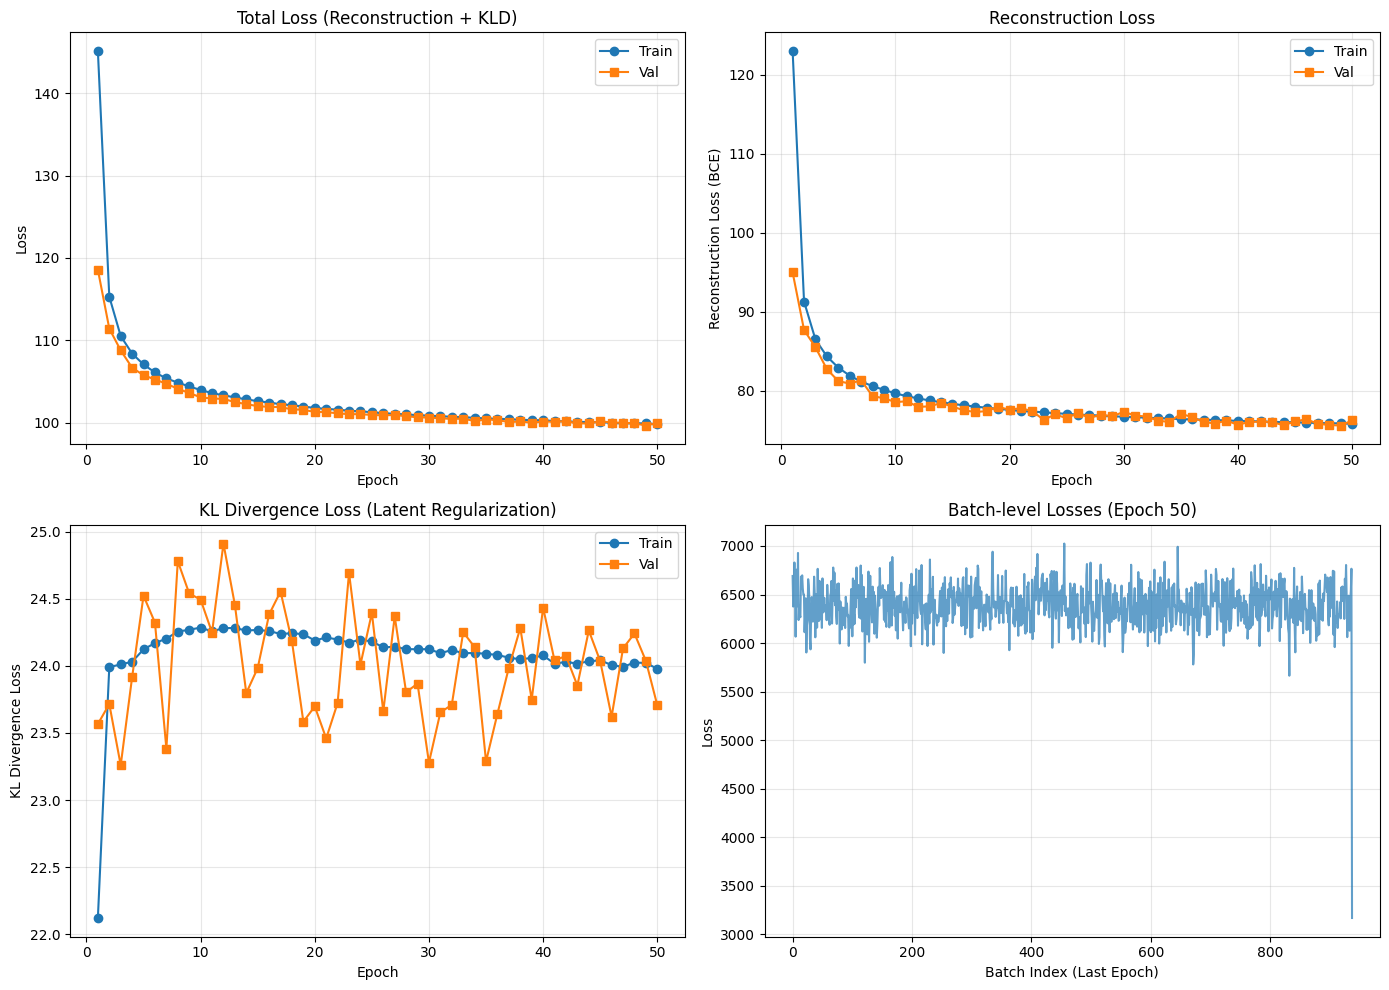

Training curves saved to: ./training_results/training_curves.png

✓ All training data and visualizations saved!


In [9]:
# =====================================================
# SAVE TRAINING HISTORY AND MODEL
# =====================================================

# Create directory for results if it doesn't exist
os.makedirs('./training_results', exist_ok=True)

# Save training history as pickle (for later loading)
history_path = './training_results/vae_training_history.pkl'
with open(history_path, 'wb') as f:
    pickle.dump(training_history, f)
print(f"Training history saved to: {history_path}")

# Save model checkpoint
model_path = './training_results/vae_model.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': EPOCHS,
    'latent_dim': LATENT_DIM,
    'config': {
        'LATENT_DIM': LATENT_DIM,
        'BATCH_SIZE': BATCH_SIZE,
        'LR': LR,
        'EPOCHS': EPOCHS
    }
}, model_path)
print(f"Model saved to: {model_path}")

# =====================================================
# QUICK VISUALIZATION: Training curves
# =====================================================

# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Total Loss
axes[0, 0].plot(training_history['epoch'], training_history['total_loss'], label='Train', marker='o')
axes[0, 0].plot(training_history['epoch'], training_history['val_loss'], label='Val', marker='s')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Total Loss (Reconstruction + KLD)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Reconstruction Loss
axes[0, 1].plot(training_history['epoch'], training_history['recon_loss'], label='Train', marker='o')
axes[0, 1].plot(training_history['epoch'], training_history['val_recon'], label='Val', marker='s')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Reconstruction Loss (BCE)')
axes[0, 1].set_title('Reconstruction Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: KLD Loss
axes[1, 0].plot(training_history['epoch'], training_history['kld_loss'], label='Train', marker='o')
axes[1, 0].plot(training_history['epoch'], training_history['val_kld'], label='Val', marker='s')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('KL Divergence Loss')
axes[1, 0].set_title('KL Divergence Loss (Latent Regularization)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Last epoch batch losses
axes[1, 1].plot(training_history['batch_losses'][-1], alpha=0.7)
axes[1, 1].set_xlabel('Batch Index (Last Epoch)')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].set_title(f'Batch-level Losses (Epoch {EPOCHS})')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./training_results/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("Training curves saved to: ./training_results/training_curves.png")
print("\n✓ All training data and visualizations saved!")

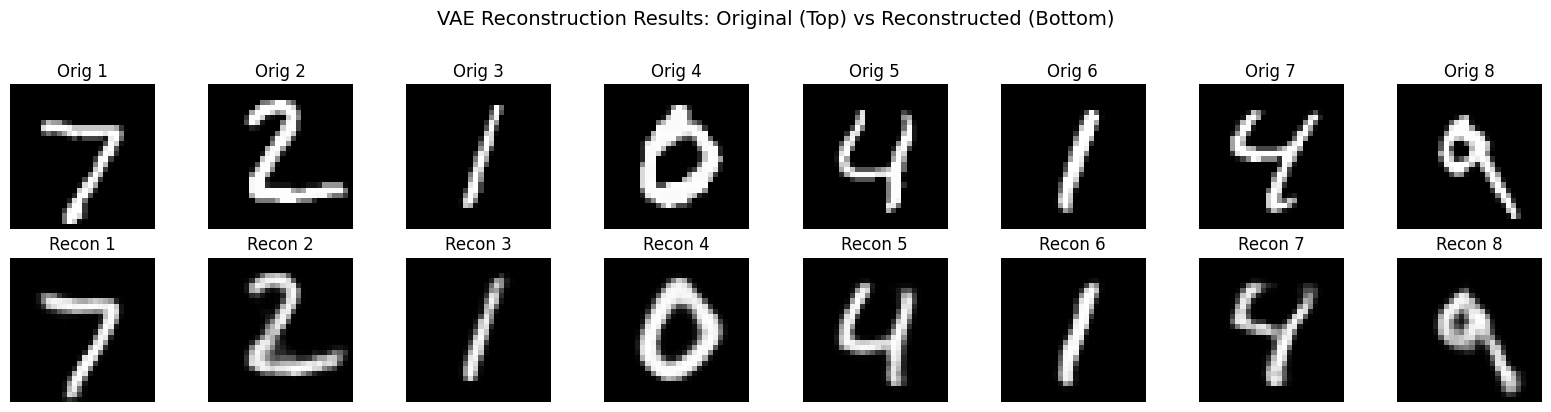

Reconstruction visualization saved to: ./training_results/reconstructions.png


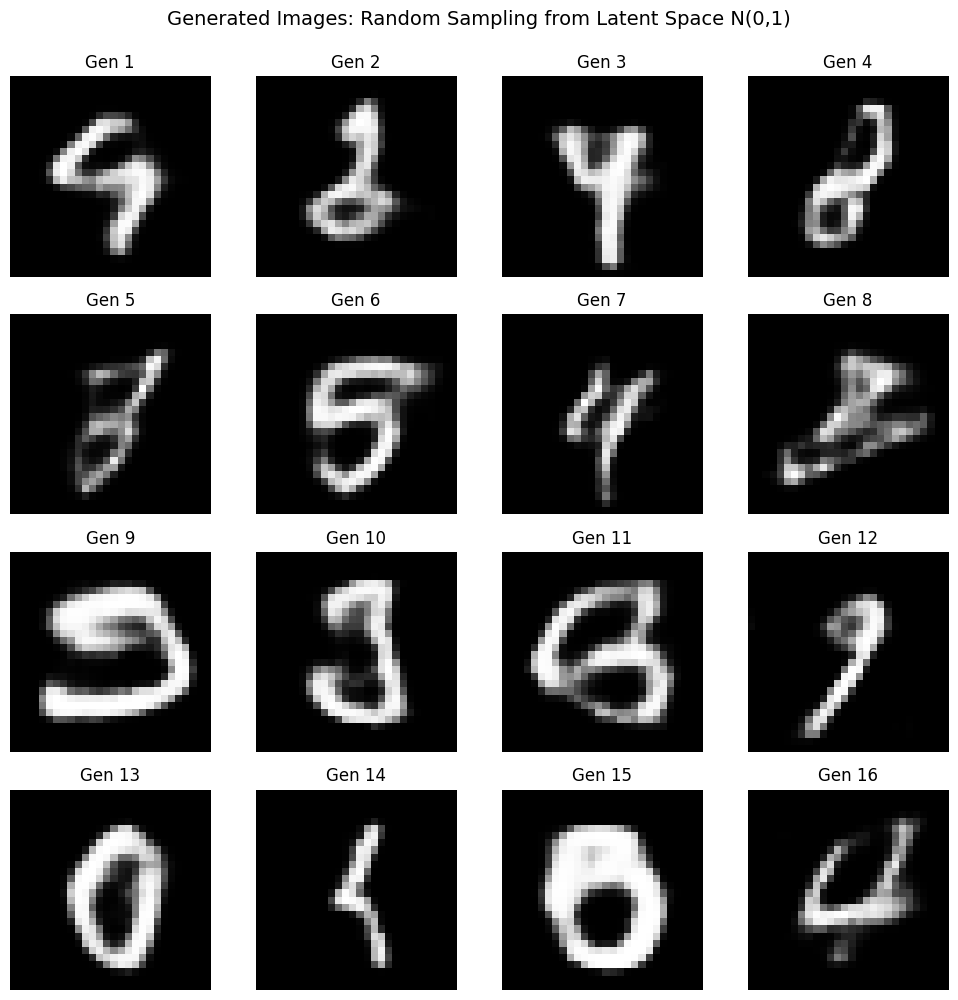

Generated images saved to: ./training_results/generated_images.png

All visualizations complete!


In [10]:
# =====================================================
# VISUALIZATION: Reconstructions and latent space exploration
# =====================================================

# Set model to evaluation mode
model.eval()

# === RECONSTRUCTION VISUALIZATION ===
# Show original vs reconstructed images
with torch.no_grad():
    # Get a batch of images
    x_orig, _ = next(iter(val_loader))
    x_orig = x_orig.to(device)

    # Forward pass
    x_recon, mu, logvar = model(x_orig)

    # Create figure: Original and Reconstructed
    fig, axes = plt.subplots(2, 8, figsize=(16, 4))

    for idx in range(8):
        # Original images
        axes[0, idx].imshow(x_orig[idx].cpu().squeeze(), cmap='gray')
        axes[0, idx].set_title(f"Orig {idx+1}")
        axes[0, idx].axis('off')

        # Reconstructed images
        axes[1, idx].imshow(x_recon[idx].cpu().squeeze(), cmap='gray')
        axes[1, idx].set_title(f"Recon {idx+1}")
        axes[1, idx].axis('off')

    fig.suptitle("VAE Reconstruction Results: Original (Top) vs Reconstructed (Bottom)",
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('./training_results/reconstructions.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("Reconstruction visualization saved to: ./training_results/reconstructions.png")

# === LATENT SPACE GENERATION ===
# Generate new images by sampling from latent space
with torch.no_grad():
    # Sample random latent codes from standard normal
    z_random = torch.randn(16, LATENT_DIM).to(device)

    # Decode to generate images
    decoder_input = model.decoder_input(z_random)
    generated = model.decoder(decoder_input)

    # Plot generated images
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))

    for idx in range(16):
        row, col = idx // 4, idx % 4
        axes[row, col].imshow(generated[idx].cpu().squeeze(), cmap='gray')
        axes[row, col].set_title(f"Gen {idx+1}")
        axes[row, col].axis('off')

    fig.suptitle("Generated Images: Random Sampling from Latent Space N(0,1)",
                 fontsize=14, y=0.995)
    plt.tight_layout()
    plt.savefig('./training_results/generated_images.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("Generated images saved to: ./training_results/generated_images.png")

print("\nAll visualizations complete!")

In [11]:
# the following code does 2 things
# For every $28 \times 28$ image in the original dataset,
# the code passes it through the Encoder.
# It ignores the reconstruction and only grabs the mu (mean)
# vector from the bottleneck. This mu is the most stable "shorthand"
# representation of that specific digit.
# basically this is passing all the data through the vae to end up with
#  98% reduced data
# Original MNIST Shape: (60000, 1, 28, 28), new shape: (60000, 16)
import torch
import numpy as np

@torch.no_grad()
def create_latent_dataset(vae_model, dataloader):
    vae_model.eval()
    all_latents = []
    all_labels = []

    print("Extracting latents from MNIST...")
    for images, labels in dataloader:
        images = images.to(device)
        # We use 'mu' as the representative latent for the image
        _, mu, _ = vae_model(images)

        all_latents.append(mu.cpu().numpy())
        all_labels.append(labels.numpy())

    # Concatenate everything into large numpy arrays
    latents = np.concatenate(all_latents, axis=0)
    labels = np.concatenate(all_labels, axis=0)

    return latents, labels

# Execute extraction
latents_train, labels_train = create_latent_dataset(model, train_loader)
print(f"Extraction complete. New dataset shape: {latents_train.shape}")

import os

# 1. Extract Latents
# Using the function from the previous step
latents_train, labels_train = create_latent_dataset(model, train_loader)
latents_val, labels_val = create_latent_dataset(model, val_loader)

# 2. Save to Colab disk
os.makedirs('./latent_data', exist_ok=True)
np.save('./latent_data/mnist_latents_train.npy', latents_train)
np.save('./latent_data/mnist_labels_train.npy', labels_train)
np.save('./latent_data/mnist_latents_val.npy', latents_val)
np.save('./latent_data/mnist_labels_val.npy', labels_val)

print(f"latent dataset saved.")
print(f"Train Shape: {latents_train.shape} | Val Shape: {latents_val.shape}")

Extracting latents from MNIST...
Extraction complete. New dataset shape: (60000, 16)
Extracting latents from MNIST...
Extracting latents from MNIST...
latent dataset saved.
Train Shape: (60000, 16) | Val Shape: (10000, 16)


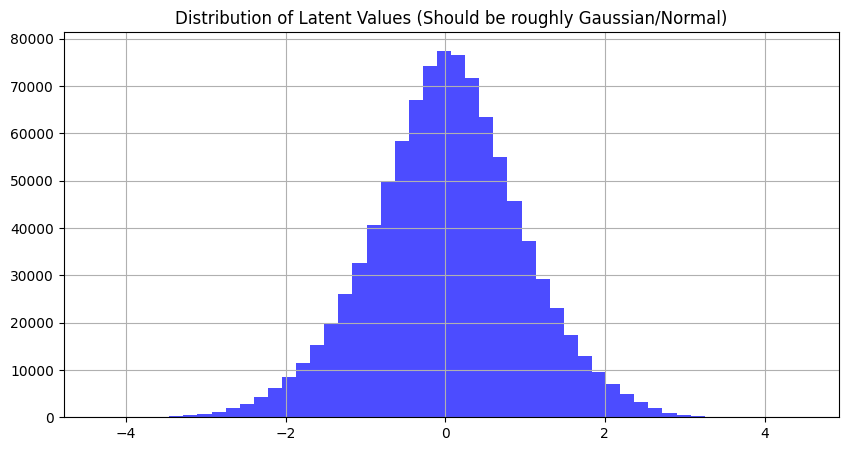

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(latents_train.flatten(), bins=50, color='blue', alpha=0.7)
plt.title("Distribution of Latent Values (Should be roughly Gaussian/Normal)")
plt.grid(True)
plt.show()

In [13]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
import math

# 1. Load the pre-extracted data
class LatentMNISTDataset(Dataset):
    def __init__(self, latents_path):
        # Load the numpy array and convert to PyTorch FloatTensor
        self.latents = torch.from_numpy(np.load(latents_path)).float()

    def __len__(self):
        return len(self.latents)

    def __getitem__(self, idx):
        # We only need the latents for unconditional diffusion
        return self.latents[idx]

# Create the new loader (using your Colab file path)
latent_dataset = LatentMNISTDataset('./latent_data/mnist_latents_train.npy')
latent_loader = DataLoader(latent_dataset, batch_size=128, shuffle=True)

print(f"Loaded {len(latent_dataset)} latent vectors for training.")

Loaded 60000 latent vectors for training.


In [14]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class ResidualLinearBlock(nn.Module):
    def __init__(self, in_features, out_features, time_emb_dim):
        super().__init__()
        # Standard MLP layers
        self.mlp = nn.Sequential(
            nn.Linear(in_features, out_features),
            nn.LayerNorm(out_features),
            nn.GELU()
        )
        # Time injection layer
        self.time_mlp = nn.Sequential(
            nn.GELU(),
            nn.Linear(time_emb_dim, out_features)
        )
        # Skip connection adapter (if dimensions change)
        self.skip = nn.Linear(in_features, out_features) if in_features != out_features else nn.Identity()

    def forward(self, x, t):
        # Process input
        h = self.mlp(x)
        # Inject time embedding (Addition, just like your U-Net)
        time_emb = self.time_mlp(t)
        h = h + time_emb
        # Residual skip connection
        return h + self.skip(x)

class LatentDiffusionMLP(nn.Module):
    def __init__(self, latent_dim=16, hidden_dim=256, time_emb_dim=128, num_layers=4):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.GELU()
        )

        # Input layer
        self.input_proj = nn.Linear(latent_dim, hidden_dim)

        # Deep residual layers
        self.res_blocks = nn.ModuleList([
            ResidualLinearBlock(hidden_dim, hidden_dim, time_emb_dim)
            for _ in range(num_layers)
        ])

        # Output layer (Maps back to 16 dimensions)
        self.output_proj = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x, time):
        # 1. Embed time
        t = self.time_mlp(time)

        # 2. Project input to higher dimension
        x = self.input_proj(x)

        # 3. Pass through residual blocks
        for block in self.res_blocks:
            x = block(x, t)

        # 4. Project back to latent space
        return self.output_proj(x)

# Initialize the model
diffusion_model = LatentDiffusionMLP(latent_dim=16).to('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Latent Diffusion Engine ready with {sum(p.numel() for p in diffusion_model.parameters()):,} parameters.")


Latent Diffusion Engine ready with 422,288 parameters.


In [15]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 1. Setup Device and Hyperparameters
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TIMESTEPS = 1000

# 2. Define the Linear Noise Schedule
# We start with a tiny bit of noise (1e-4) and scale up to (0.02)
betas = torch.linspace(1e-4, 0.02, TIMESTEPS).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

# Pre-compute the square roots for the forward diffusion formula:
# x_t = sqrt(alpha_cumprod) * x_0 + sqrt(1 - alpha_cumprod) * noise
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

def q_sample(x_0, t, noise):
    """
    The Forward Process: Adds the exact right amount of noise to the latent
    vector 'x_0' for a given timestep 't', all in one mathematical step.
    """
    sqrt_alpha_cumprod_t = sqrt_alphas_cumprod[t].view(-1, 1)
    sqrt_one_minus_alpha_cumprod_t = sqrt_one_minus_alphas_cumprod[t].view(-1, 1)

    return sqrt_alpha_cumprod_t * x_0 + sqrt_one_minus_alpha_cumprod_t * noise

Starting Latent Diffusion Training...
Epoch [  1/150] | Average MSE Loss: 0.30609
Epoch [ 10/150] | Average MSE Loss: 0.24733
Epoch [ 20/150] | Average MSE Loss: 0.24092
Epoch [ 30/150] | Average MSE Loss: 0.23432
Epoch [ 40/150] | Average MSE Loss: 0.23365
Epoch [ 50/150] | Average MSE Loss: 0.23203
Epoch [ 60/150] | Average MSE Loss: 0.22743
Epoch [ 70/150] | Average MSE Loss: 0.23135
Epoch [ 80/150] | Average MSE Loss: 0.22830
Epoch [ 90/150] | Average MSE Loss: 0.22968
Epoch [100/150] | Average MSE Loss: 0.22935
Epoch [110/150] | Average MSE Loss: 0.22689
Epoch [120/150] | Average MSE Loss: 0.22494
Epoch [130/150] | Average MSE Loss: 0.22437
Epoch [140/150] | Average MSE Loss: 0.22734
Epoch [150/150] | Average MSE Loss: 0.22376
Latent Diffusion Training Complete!


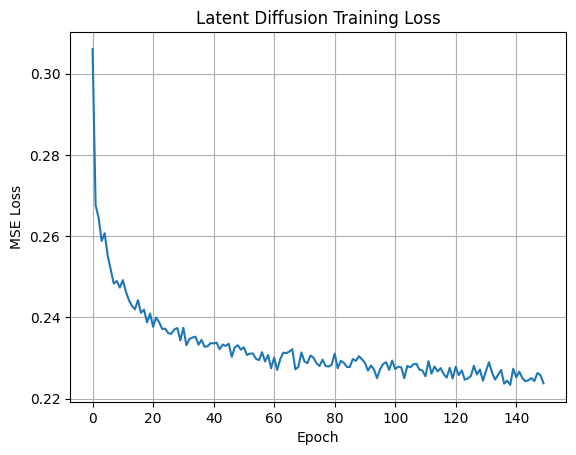

In [16]:
import torch.optim as optim

# Initialize Optimizer
optimizer = optim.Adam(diffusion_model.parameters(), lr=1e-3)
EPOCHS = 150 # This will run very fast on latents!

print("Starting Latent Diffusion Training...")
print("="*50)

diffusion_model.train()
training_loss_history = []

for epoch in range(EPOCHS):
    total_loss = 0.0

    # We use 'latent_loader' which we defined in the previous step
    for batch_latents in latent_loader:
        # 1. Move latents to GPU
        batch_latents = batch_latents.to(device)
        batch_size = batch_latents.shape[0]

        # 2. Sample random timesteps for each vector in the batch
        t = torch.randint(0, TIMESTEPS, (batch_size,), device=device).long()

        # 3. Generate random Gaussian noise of the same shape (B, 16)
        noise = torch.randn_like(batch_latents)

        # 4. Add noise to the latents (Forward Process)
        noisy_latents = q_sample(batch_latents, t, noise)

        # 5. Predict the noise using our MLP
        predicted_noise = diffusion_model(noisy_latents, t)

        # 6. Calculate Loss (Mean Squared Error)
        loss = F.mse_loss(predicted_noise, noise)

        # 7. Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(latent_loader)
    training_loss_history.append(avg_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:3d}/{EPOCHS}] | Average MSE Loss: {avg_loss:.5f}")

print("="*50)
print("Latent Diffusion Training Complete!")

# Plot the training curve
plt.plot(training_loss_history)
plt.title("Latent Diffusion Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

1. Generating pure noise in Latent Space...
2. Denoising latents over 1000 steps...
3. Decoding clean latents into pixel space...


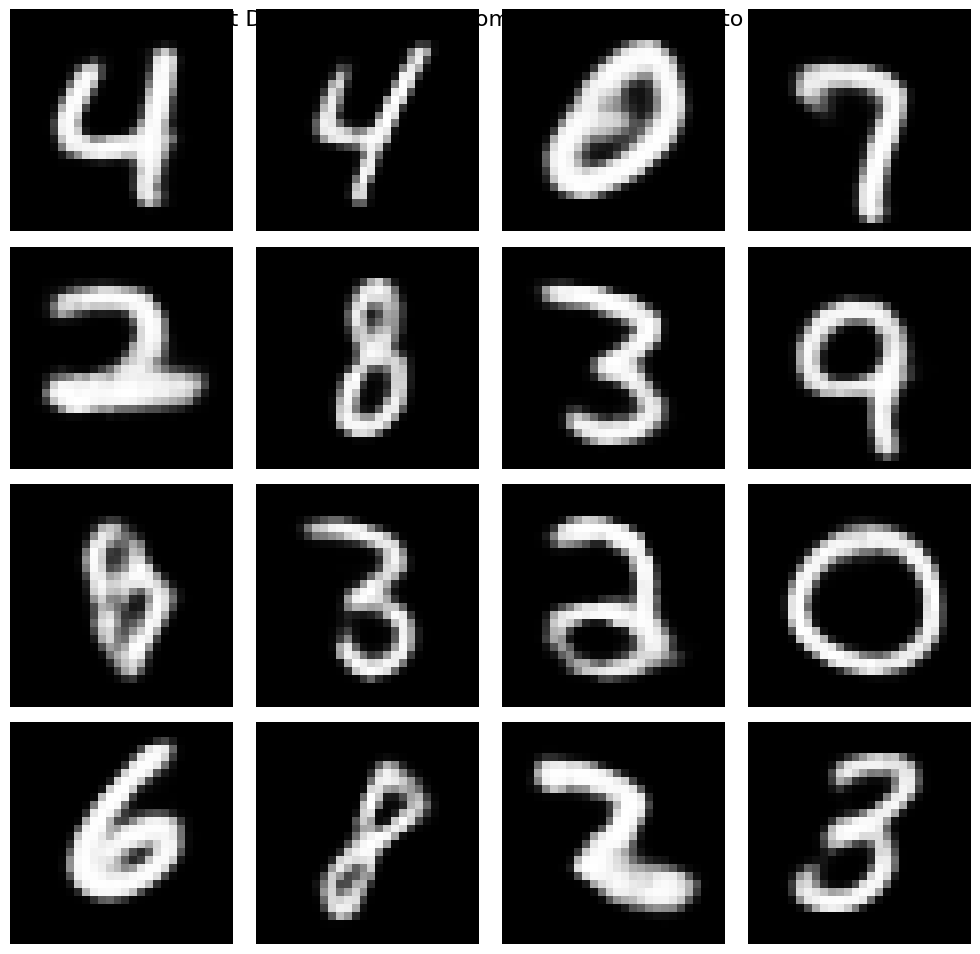

In [17]:
import torch
import matplotlib.pyplot as plt

@torch.no_grad()
def generate_images_from_latents(diffusion_model, vae_model, num_samples=16, latent_dim=16, timesteps=1000):
    # Ensure both models are in evaluation mode
    diffusion_model.eval()
    vae_model.eval()

    print("1. Generating pure noise in Latent Space...")
    # Start with pure random noise vectors [Batch, 16]
    z = torch.randn(num_samples, latent_dim).to(device)

    print(f"2. Denoising latents over {timesteps} steps...")
    for i in reversed(range(timesteps)):
        # Create a tensor of the current timestep for the whole batch
        t = torch.full((num_samples,), i, device=device, dtype=torch.long)

        # The MLP predicts the noise added to the vectors
        predicted_noise = diffusion_model(z, t)

        # Fetch the pre-computed math constants for this step
        alpha = alphas[i]
        alpha_cumprod = alphas_cumprod[i]
        beta = betas[i]

        # Langevin noise injection (add randomness to prevent collapse)
        if i > 0:
            noise = torch.randn_like(z)
        else:
            noise = torch.zeros_like(z) # No extra noise on the very last step

        # The Reverse DDPM Equation (operating entirely on 16-D vectors)
        z = (1 / torch.sqrt(alpha)) * (z - ((1 - alpha) / torch.sqrt(1 - alpha_cumprod)) * predicted_noise) + torch.sqrt(beta) * noise

    print("3. Decoding clean latents into pixel space...")
    # Now that 'z' is a batch of clean MNIST latents, pass it to the frozen VAE Decoder
    decoder_input = vae_model.decoder_input(z)
    generated_images = vae_model.decoder(decoder_input)

    return generated_images

# Execute the pipeline
generated_images = generate_images_from_latents(diffusion_model, model, num_samples=16)

# =====================================================
# VISUALIZATION: Plot the newly generated digits
# =====================================================
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for idx in range(16):
    row, col = idx // 4, idx % 4
    # The VAE outputs [B, 1, 28, 28]. Squeeze it to [28, 28] for matplotlib
    axes[row, col].imshow(generated_images[idx].cpu().squeeze(), cmap='gray')
    axes[row, col].axis('off')

fig.suptitle("Latent Diffusion Outputs: From Pure Latent Noise to Pixels", fontsize=16, y=0.95)
plt.tight_layout()
plt.show()